─── Performance por Canal de Aquisição ───


Canal,Total Pedidos,Ticket Médio,Taxa Cancelamento
Tráfego Pago,3935,"R$ 2.553,51",30.7%
Indicação,3646,"R$ 2.565,98",12.4%
Orgânico,3595,"R$ 2.521,15",11.8%
Redes Sociais,3745,"R$ 2.657,17",11.7%



🔴 Maior taxa de cancelamento : Tráfego Pago
🟢 Maior ticket médio         : Redes Sociais


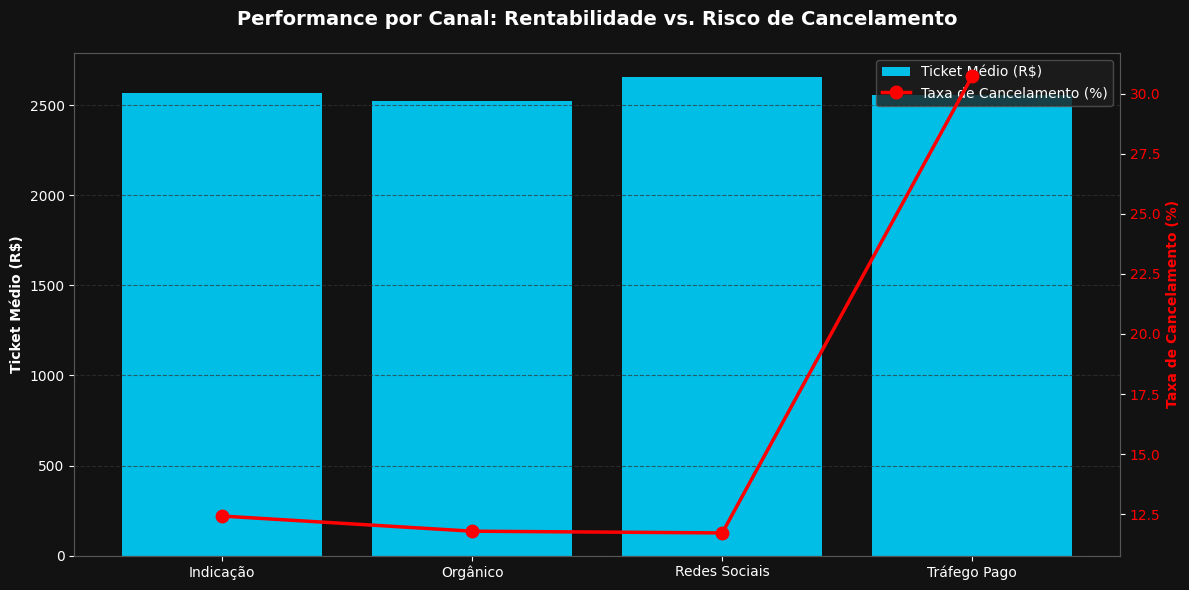

In [ ]:
#5) Qual canal de aquisição de clientes apresenta a maior taxa de cancelamento de pedidos? E qual gera o maior valor médio de compra? Cruzar clientes → pedidos.

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

DATA_DIR = Path('../data')
DARK_BG, GRID_CLR, SPINE_CLR, BLUE = '#121212', '#333333', '#555555', '#00D2FF'

plt.rcParams.update({
    'figure.facecolor': DARK_BG, 'axes.facecolor': DARK_BG,
    'axes.edgecolor': SPINE_CLR, 'axes.labelcolor': 'white',
    'xtick.color': 'white', 'ytick.color': 'white', 'text.color': 'white',
    'grid.color': GRID_CLR, 'grid.linestyle': '--', 'grid.alpha': 0.7,
    'legend.facecolor': '#1e1e1e', 'legend.edgecolor': SPINE_CLR,
})

CANAL_LABEL = {
    'organico': 'Orgânico', 'trafego_pago': 'Tráfego Pago',
    'redes_sociais': 'Redes Sociais', 'indicacao': 'Indicação',
}

def brl(valor: float) -> str: return f"R$ {valor:,.2f}".replace(',', 'v').replace('.', ',').replace('v', '.')
def pct(valor: float, casas: int = 1) -> str: return f"{valor:.{casas}f}%"
def load_clean(tabela: str) -> pd.DataFrame:
    path = DATA_DIR / f'{tabela}_limpo.csv'
    if not path.exists(): raise FileNotFoundError("Erro: Rode o script ETL (Q6) primeiro.")
    return pd.read_csv(path)

df_pedidos  = load_clean('pedidos')
df_clientes = load_clean('clientes')

df_merged = df_pedidos.merge(
    df_clientes[['id', 'canal_aquisicao']],
    left_on='cliente_id', right_on='id',
    how='inner', validate='many_to_one', suffixes=('_pedido', '_cliente')
)

df_merged['canal_label'] = (
    df_merged['canal_aquisicao'].map(CANAL_LABEL)
    .fillna(df_merged['canal_aquisicao'].str.replace('_', ' ').str.title())
)

canal_perf = df_merged.groupby('canal_label').agg(
    total_pedidos  = ('id_pedido', 'count'),
    cancelamentos  = ('status',    lambda s: (s == 'cancelado').sum()),
    ticket_medio   = ('valor_total', 'mean'),
).reset_index()

canal_perf['taxa_cancelamento'] = (canal_perf['cancelamentos'] / canal_perf['total_pedidos'] * 100)

tabela_q5 = canal_perf.copy()
tabela_q5['Ticket Médio']      = tabela_q5['ticket_medio'].apply(brl)
tabela_q5['Taxa Cancelamento'] = tabela_q5['taxa_cancelamento'].apply(pct)
tabela_q5 = tabela_q5.rename(columns={'canal_label': 'Canal', 'total_pedidos':'Total Pedidos', 'cancelamentos':'Cancelamentos'})

print("─── Performance por Canal de Aquisição ───")
display(
    tabela_q5[['Canal', 'Total Pedidos', 'Ticket Médio', 'Taxa Cancelamento']]
    .sort_values('Taxa Cancelamento', ascending=False).style.hide(axis='index')
)

canal_cancel = canal_perf.loc[canal_perf['taxa_cancelamento'].idxmax(), 'canal_label']
canal_ticket = canal_perf.loc[canal_perf['ticket_medio'].idxmax(),      'canal_label']
print(f"\n🔴 Maior taxa de cancelamento : {canal_cancel}")
print(f"🟢 Maior ticket médio         : {canal_ticket}")

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

canais = canal_perf['canal_label'].tolist()
x      = range(len(canais))

ax1.bar(x, canal_perf['ticket_medio'], color=BLUE, alpha=0.9, label='Ticket Médio (R$)')
ax2.plot(x, canal_perf['taxa_cancelamento'], color='red', marker='o', linewidth=2.5, markersize=9, label='Taxa de Cancelamento (%)')

ax1.set_xticks(list(x))
ax1.set_xticklabels(canais)
ax1.set_ylabel('Ticket Médio (R$)', fontweight='bold')
ax2.set_ylabel('Taxa de Cancelamento (%)', fontweight='bold', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax1.set_title('Performance por Canal: Rentabilidade vs. Risco de Cancelamento', fontsize=14, fontweight='bold', pad=20)
ax1.grid(True, axis='y')

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()